In [1]:
import pandas as pd
dataset=pd.read_csv("PrePlacement.csv")

In [2]:
dataset

,sl_no,ssc_p,hsc_p,degree_p,etest_p,mba_p,salary,gender,ssc_b,hsc_b,hsc_s,degree_t,workex,specialisation,status
0,1.0,67.00,91.00,58.00,55.0,58.80,270000.000000,M,Others,Others,Commerce,Sci&Tech,No,Mkt&HR,Placed
1,2.0,79.33,78.33,77.48,86.5,66.28,200000.000000,M,Central,Others,Science,Sci&Tech,Yes,Mkt&Fin,Placed
2,3.0,65.00,68.00,64.00,75.0,57.80,250000.000000,M,Central,Central,Arts,Comm&Mgmt,No,Mkt&Fin,Placed
3,4.0,56.00,52.00,52.00,66.0,59.43,288655.405405,M,Central,Central,Science,Sci&Tech,No,Mkt&HR,Not Placed
4,5.0,85.80,73.60,73.30,96.8,55.50,425000.000000,M,Central,Central,Commerce,Comm&Mgmt,No,Mkt&Fin,Placed
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
210,211.0,80.60,82.00,77.60,91.0,74.49,400000.000000,M,Others,Others,Commerce,Comm&Mgmt,No,Mkt&Fin,Placed
211,212.0,58.00,60.00,72.00,74.0,53.62,275000.000000,M,Others,Others,Science,Sci&Tech,No,Mkt&Fin,Placed
212,213.0,67.00,67.00,73.00,59.0,69.72,295000.000000,M,Others,Others,Commerce,Comm&Mgmt,Yes,Mkt&Fin,Placed
213,214.0,74.00,66.00,58.00,70.0,60.23,204000.000000,F,Others,Others,Commerce,Comm&Mgmt,No,Mkt&HR,Placed


In [11]:
import seaborn as sns

<Axes: xlabel='ssc_p', ylabel='Count'>

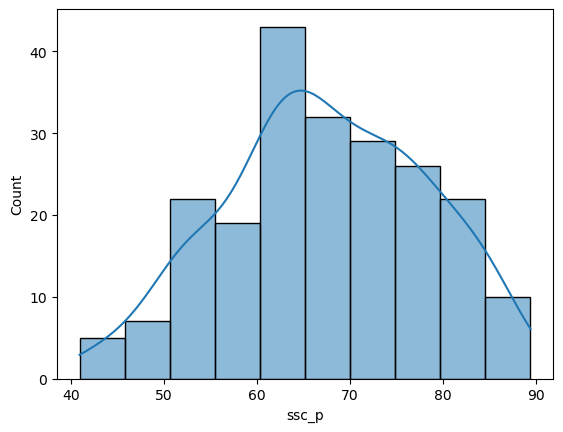

In [13]:
sns.histplot(dataset["ssc_p"],kde=True)

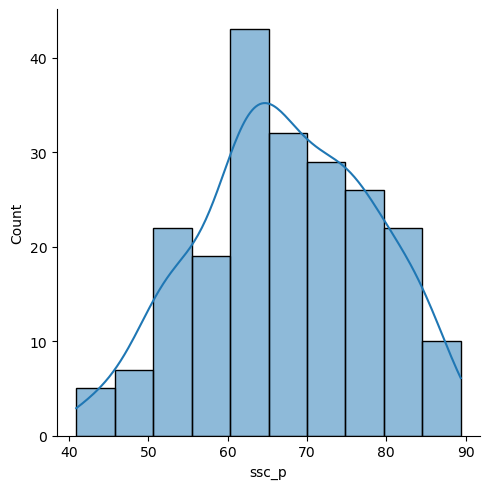

In [14]:
sns.displot(dataset["ssc_p"],kde=True)

In [26]:
def get_pdf_probabilities (dataset,startrange,endrange):

    from matplotlib import pyplot
    from scipy.stats import norm
    import seaborn as sns
    
    ax=sns.distplot(dataset,kde=True,kde_kws={'color':'blue'},color='Green')
    pyplot.axvline(startrange,color='Red')
    pyplot.axvline(endrange,color='Red')
    #generate sample
    sample=dataset
    #Calculate parameters
    sample_mean=sample.mean()
    sample_std=sample.std()
    print('Mean=%.3f, Standard Deviation=%.3f'  % (sample_mean , sample_std))
    #Define the distribution
    dist=norm(sample_mean,sample_std)
    #sample probabilites for a range of outcomes
    values=[value for value in range ( startrange , endrange )]
    probabilites=[dist.pdf(value) for value in values]
    prob=sum(probabilites)
    print(f"The area between ranges {startrange},{endrange} : { prob}")
    #print("The area between ranges ({},{}) : {} ", format (startrange,endrange,sum(probabilites)))
    return prob
        

Mean=67.303, Standard Deviation=10.827
The area between ranges 50,90 : 0.9298623989198703


C:\Users\Anand\AppData\Local\Temp\ipykernel_2984\3051075203.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  ax=sns.distplot(dataset,kde=True,kde_kws={'color':'blue'},color='Green')


np.float64(0.9298623989198703)

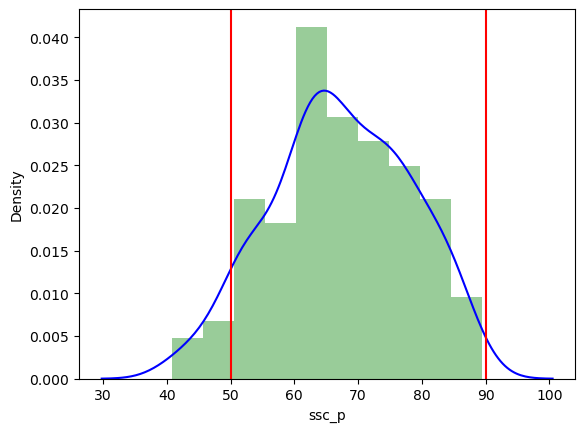

In [29]:
get_pdf_probabilities (dataset["ssc_p"],50,90)

In [32]:
from statsmodels.distributions.empirical_distribution import ECDF
ecdf=ECDF(dataset["ssc_p"])
ecdf(78)  ## % wise we can check here eg 78%

np.float64(0.827906976744186)

# standard normal distributions

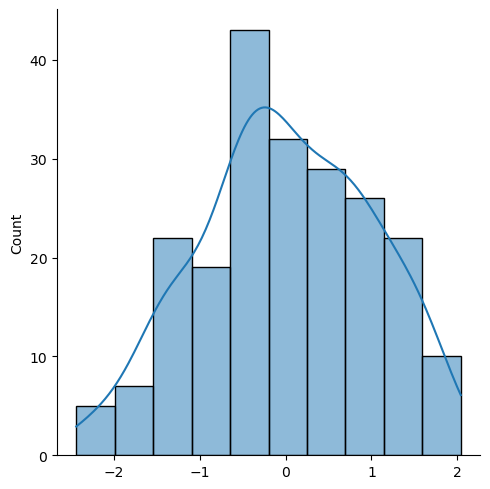

In [7]:
import seaborn as sns
mean=dataset['ssc_p'].mean()
std=dataset['ssc_p'].std()
values=[i for i in dataset['ssc_p']]
z_score=[((j-mean)/std) for j in values]
sns.displot(z_score,kde=True)